In [68]:
import copy

import matplotlib.pyplot as plt
from matplotlib.pyplot import plot, figure, show
import numpy as np
import scipy.io as sio
import scipy.signal
from rich import print

v=array([ 0. ,  0.1,  0.2,  0.3,  0.4,  0.5,  0.6,  0.7,  0.8,  0.9,  1. ,
        1.1,  1.2,  1.3,  1.4,  1.5,  1.6,  1.7,  1.8,  1.9,  2. ,  2.1,
        2.2,  2.3,  2.4,  2.5,  2.6,  2.7,  2.8,  2.9,  3. ,  3.1,  3.2,
        3.3,  3.4,  3.5,  3.6,  3.7,  3.8,  3.9,  4. ,  4.1,  4.2,  4.3,
        4.4,  4.5,  4.6,  4.7,  4.8,  4.9,  5. ,  5.1,  5.2,  5.3,  5.4,
        5.5,  5.6,  5.7,  5.8,  5.9,  6. ,  6.1,  6.2,  6.3,  6.4,  6.5,
        6.6,  6.7,  6.8,  6.9,  7. ,  7.1,  7.2,  7.3,  7.4,  7.5,  7.6,
        7.7,  7.8,  7.9,  8. ,  8.1,  8.2,  8.3,  8.4,  8.5,  8.6,  8.7,
        8.8,  8.9,  9. ,  9.1,  9.2,  9.3,  9.4,  9.5,  9.6,  9.7,  9.8,
        9.9, 10. ])

y=array([ 0.        ,  0.09983342,  0.19866933,  0.29552021,  0.38941834,
        0.47942554,  0.56464247,  0.64421769,  0.71735609,  0.78332691,
        0.84147098,  0.89120736,  0.93203909,  0.96355819,  0.98544973,
        0.99749499,  0.9995736 ,  0.99166481,  0.97384763,  0.94630009,
        0.90929743,  0.86320937,  0.8084964 ,  0.74570521,  0.67546318,
        0.59847214,  0.51550137,  0.42737988,  0.33498815,  0.23924933,
        0.14112001,  0.04158066, -0.05837414, -0.15774569, -0.2555411 ,
       -0.35078323, -0.44252044, -0.52983614, -0.61185789, -0.68776616,
       -0.7568025 , -0.81827711, -0.87157577, -0.91616594, -0.95160207,
       -0.97753012, -0.993691  , -0.99992326, -0.99616461, -0.98245261,
       -0.95892427, -0.92581468, -0.88345466, -0.83226744, -0.77276449,
       -0.70554033, -0.63126664, -0.55068554, -0.46460218, -0.37387666,
       -0.2794155 , -0.1821625 , -0.0830894 ,  0.0168139 ,  0.1165492 ,
        0.21511999,  0.31154136,  0.40484992,  0.49411335,  0.57843976,
        0.6569866 ,  0.72896904,  0.79366786,  0.85043662,  0.8987081 ,
        0.93799998,  0.96791967,  0.98816823,  0.99854335,  0.99894134,
        0.98935825,  0.96988981,  0.94073056,  0.90217183,  0.85459891,
        0.79848711,  0.7343971 ,  0.66296923,  0.58491719,  0.50102086,
        0.41211849,  0.31909836,  0.22288991,  0.12445442,  0.02477543,
       -0.07515112, -0.17432678, -0.27176063, -0.36647913, -0.45753589,
       -0.54402111])

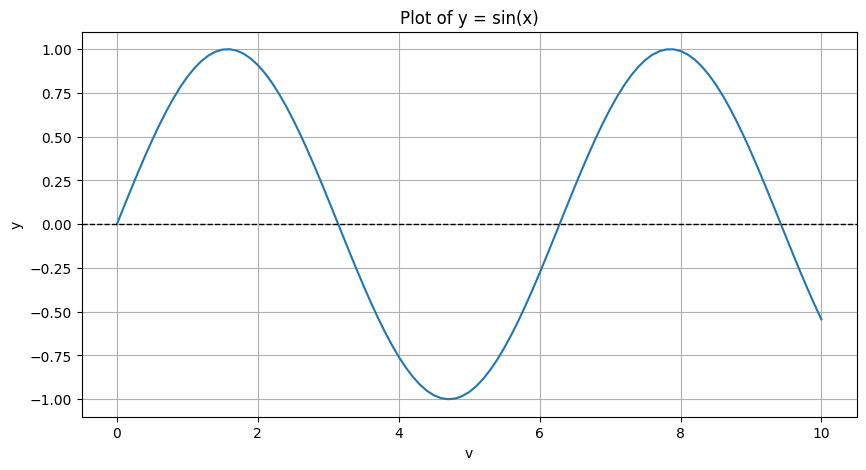

In [69]:
v = np.arange(0, 10 + 0.1, 0.1)
print(f"{v=}")

y = np.sin(v)
print(f"{y=}")

# plot
def plotear(x, y, figsize=(10, 5), title="Plot of y = sin(x)", axh=True, **kwargs):
    if kwargs: print(f"using {kwargs=}")
    plt.figure(figsize=figsize)
    plt.plot(x, y, **kwargs)
    if axh:
        plt.axhline(0, color='black',linewidth=1, ls='--')
    plt.xlabel("v")
    plt.ylabel("y")
    plt.title(title)
    plt.grid()
    plt.show()

plotear(v, y, title="Plot of y = sin(x)")

## np.linspace

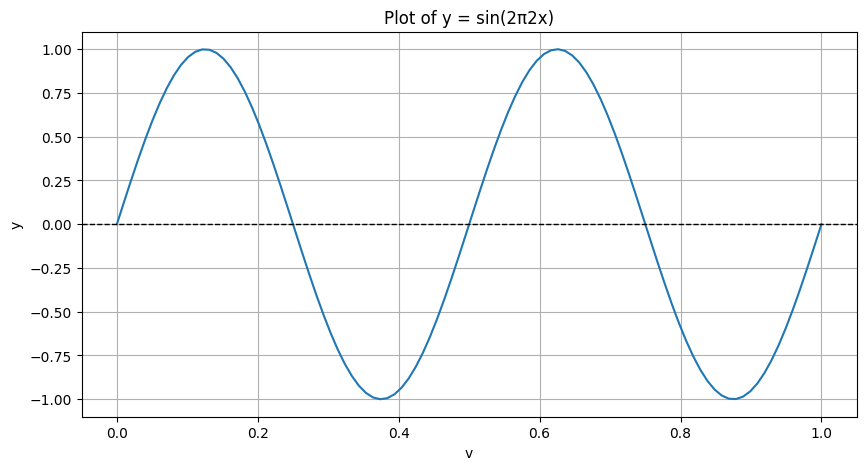

In [70]:
start = 0
end = 1

fs = 100  # Hz
npts = fs * (end - start)

x = np.linspace(start, end, npts)

f = 2  # Hz
w = 2 * np.pi * f
y = np.sin(w * x)

# plot
plotear(x, y, title="Plot of y = sin(2π2x)")

# np.arange

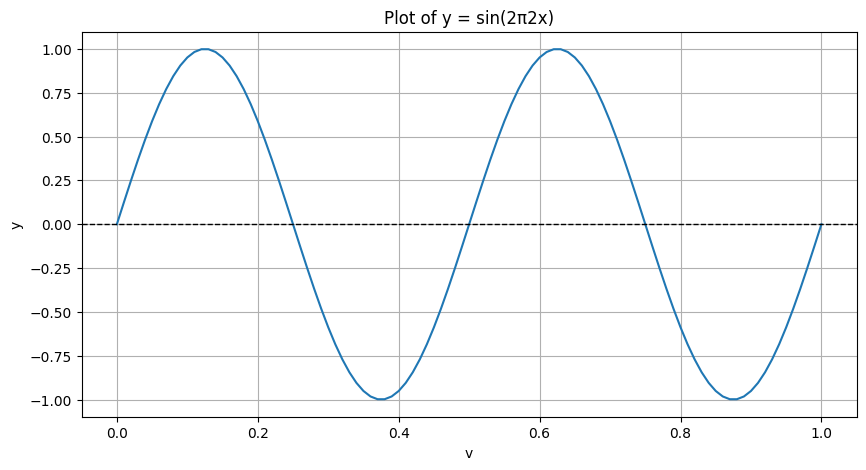

In [71]:
fs = 100  # sampling frequency
step = 1/fs
x = np.arange(0, 1+step, step)

f = 2.0  # signal frequency in Hz
w = 2 * np.pi * f  # angular frequency
y = np.sin(w * x)

# plot
plotear(x, y, title="Plot of y = sin(2π2x)")


## np.interpolate

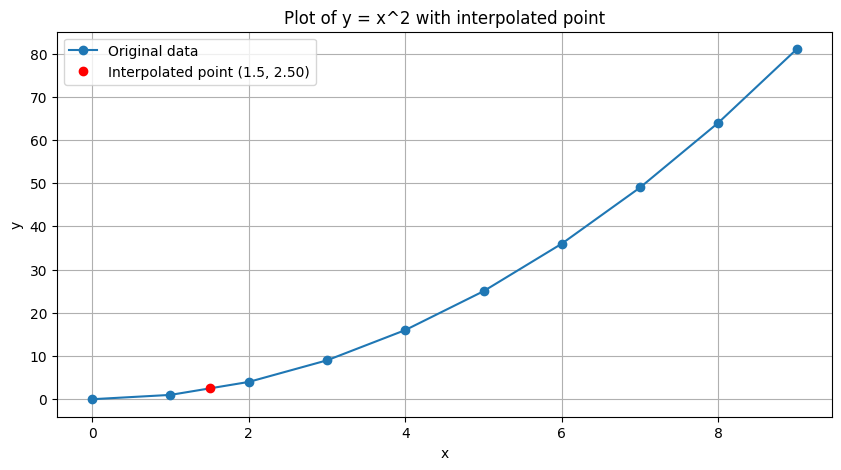

xi[0]=1.5, yi[0]=2.5

In [72]:
X_MAX = 9
x = np.arange(0, X_MAX + 1)
y = [i ** 2 for i in x]


xi = [1.5]
yi = np.interp(xi, x, y)

# plot
plt.figure(figsize=(10, 5))
plt.plot(x, y, 'o-', label='Original data')
plt.plot(xi, yi, 'ro', label=f'Interpolated point ({xi[0]}, {yi[0]:.2f})')
plt.title("Plot of y = x^2 with interpolated point")
plt.xlabel("x")
plt.ylabel("y")
plt.grid(True)
plt.legend()
plt.show()

print(f"{xi[0]=}, yi[0]={yi[0]:<5}")  # "<5" means "left-align within 5 spaces"

## add Noise

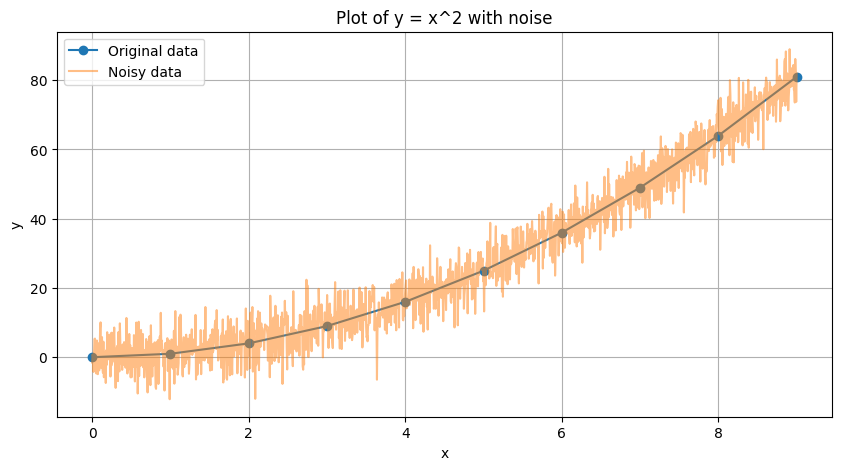

In [77]:
from operator import le


x_noise = np.linspace(0, X_MAX, 1500)
y_noise = np.interp(x_noise, x, y) + np.random.normal(loc=0, scale=5.0, size=len(x_noise))

# plot
plt.figure(figsize=(10, 5))
plt.plot(x, y, 'o-', label='Original data')
plt.plot(x_noise, y_noise, '-', label='Noisy data', alpha=0.5)
plt.title("Plot of y = x^2 with noise")
plt.xlabel("x")
plt.ylabel("y")
plt.grid(True)
plt.legend()
plt.show()



## Running Mean Filter

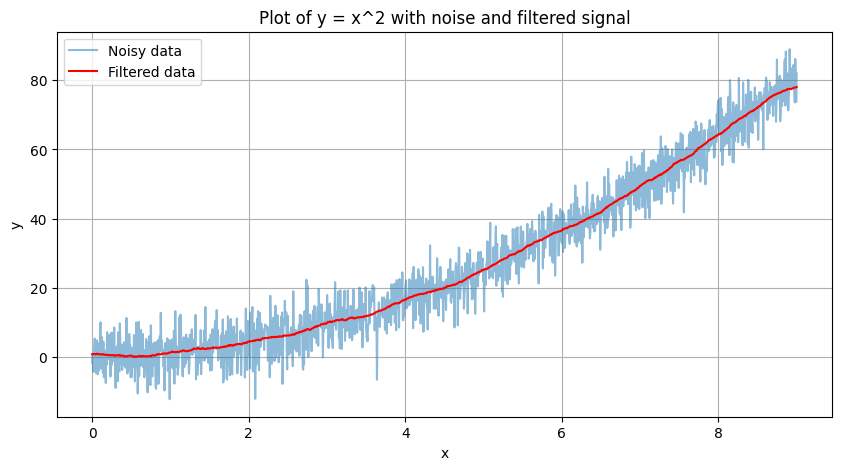

In [ ]:
filtsig = np.zeros_like(x_noise)
window_size = 100
half_window = window_size // 2

for i in range(len(x_noise)):
    filtsig[i] = np.mean(y_noise[max(0, i - half_window):min(len(y_noise), i + half_window + 1)])

# plot
plt.figure(figsize=(10, 5))
plt.plot(x_noise, y_noise, '-', label='Noisy data', alpha=0.5)
plt.plot(x_noise, filtsig, '-', label='Filtered data', color='red')
plt.title("Plot of y = x^2 with noise and filtered signal")
plt.xlabel("x")
plt.ylabel("y")
plt.grid(True)
plt.legend()
plt.show()

# using t
